## No node features GNN
This notebook contains the PoC where we use the connectivity and paths within the graph for learning and forget about all features (depth, distance to root/leaf, is leaf/is internal, etc.). The intuition behind this is that the majority of information in phylogeny is stored in the connectivity of the graph itself (adjacency matrix) and the weights of the connections. This is meant as a complimentary exploration next to the other GNN implementation. The best performing implementation is chosen for the next step.

## V 2.0.4

### KL loss has been implemente but its not learning yet. KL Neighborhood is gonna be reduced

C:\Users\sara_\anaconda3\envs\fishenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded files:
  edge_index:         (2, 45836)
  edge_weight:        (45836,)
  nodes:              (22919, 4)
  branch_dist_full:   (11460, 11460)
  species_index_df:   (11460, 2)

Graph sanity checks passed.
  num_nodes: 22919
  num_edges (directed): 45836
  num_leaf_nodes: 11460
Visualizing 34 nodes around 'Danio rerio' within 10 hops.


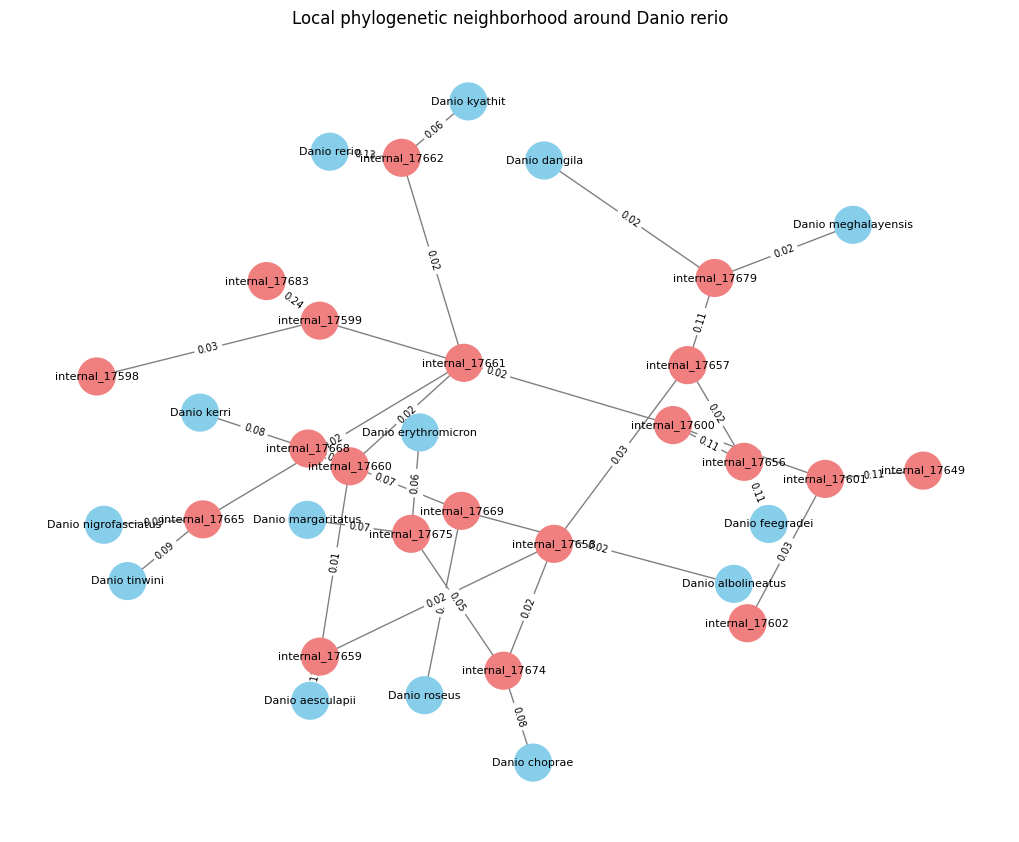


Number of leaves: 11460

Leaf distance matrix loaded and aligned.
  shape: (11460, 11460)
  min:   0.000000
  max:   1.000000

Triplet candidate pools built.
  Example anchor 0 -> pos pool size: 20, neg pool size: 3438

Using device: cpu
Epoch 001 | total_loss=0.6865 | triplet=0.2053 | kl=0.0962 | val_triplet_acc=0.3646 | spearman=0.0366
Epoch 020 | total_loss=0.6995 | triplet=0.2002 | kl=0.0999 | val_triplet_acc=0.4085 | spearman=0.0641
Epoch 040 | total_loss=0.6870 | triplet=0.2000 | kl=0.0974 | val_triplet_acc=0.4040 | spearman=0.0580
Epoch 060 | total_loss=0.6688 | triplet=0.2001 | kl=0.0937 | val_triplet_acc=0.4115 | spearman=0.0573
Epoch 080 | total_loss=0.7003 | triplet=0.2000 | kl=0.1000 | val_triplet_acc=0.4232 | spearman=0.0619
Epoch 100 | total_loss=0.6726 | triplet=0.2000 | kl=0.0945 | val_triplet_acc=0.4456 | spearman=0.0622
Epoch 120 | total_loss=0.6797 | triplet=0.2000 | kl=0.0959 | val_triplet_acc=0.4436 | spearman=0.0601
Epoch 140 | total_loss=0.7094 | triplet=0.2001 

In [1]:
# phylo_gnn_baseline.py
"""
Baseline GNN for the phylogeny modality.

Goal
-----
Learn node embeddings on the pruned fish phylogeny such that
leaf/species embeddings reflect phylogenetic branch-length distances.

This script is a cleaner and more scalable rewrite of the notebook prototype.

Main improvements over the first prototype
------------------------------------------
1. Uses sparse graph inputs directly (edge_index, edge_weight)
   instead of dense adjacency matrices for the actual model.
2. Uses edge weights inside GCNConv.
3. Uses safer node indexing from nodes.csv ("node_id") instead of relying on row index.
4. Builds a slightly richer baseline feature matrix.
5. Uses structured triplet sampling instead of fully random triplets.
6. Tracks evaluation metrics beyond training loss:
   - validation triplet accuracy
   - Spearman correlation between embedding similarity and negative tree distance
7. Saves outputs cleanly for downstream use.

Expected inputs from stage0_preprocessing.ipynb
-----------------------------------------------
output/
    processed_fishtree_edge_index.npy
    processed_fishtree_edge_weight.npy
    processed_fishtree_nodes.csv
    processed_fishtree_branch_distance.npy
    processed_fishtree_species_index.csv

Outputs written by this script
------------------------------
output/gnn_nofeatures/
    history.csv
    node_embeddings.npy
    leaf_embeddings.npy
    leaf_index_mapping.csv
    metrics_summary.csv
    loss_curve.png
    pca_leaf_embeddings.png
"""

# ============================================================
# 1. Imports
# ============================================================

from __future__ import annotations

import math
import random
from dataclasses import dataclass
from pathlib import Path
from typing import Optional

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.decomposition import PCA
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import networkx as nx

from torch_geometric.nn import GCNConv


# ============================================================
# 2. Configuration -- 
# ============================================================

@dataclass
class Config:
    # Paths
    input_dir: Path = Path("output")
    output_dir: Path = Path("output/gnn_nofeatures")

    # Reproducibility
    seed: int = 42

    # Features
    use_log_branch_sum: bool = True

    # Training
    hidden_dim: int = 64
    out_dim: int = 32
    dropout: float = 0.2
    lr: float = 1e-2
    weight_decay: float = 1e-4
    num_epochs: int = 200

    # Triplet sampling
    train_triplets_per_epoch: int = 5000
    val_triplets: int = 10000
    margin: float = 0.2
    positive_k: int = 20
    negative_quantile: float = 0.7

    # KL loss
    lambda_kl: float = 5.0 
    kl_num_anchors_per_epoch: int = 256
    temp_embed: float = 0.5 
    temp_tree: float = 0.5 
    kl_neighbor_k: int = 16

    # Evaluation
    eval_pair_sample_size: int = 50000

    # Device
    device: str = "cuda" if torch.cuda.is_available() else "cpu"


CFG = Config()


# ============================================================
# 3. Reproducibility helpers
# ============================================================

def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(CFG.seed)


# ============================================================
# 4. Load graph exports from preprocessing
# ============================================================

edge_index_path = CFG.input_dir / "processed_fishtree_edge_index.npy"
edge_weight_path = CFG.input_dir / "processed_fishtree_edge_weight.npy"
nodes_path = CFG.input_dir / "processed_fishtree_nodes.csv"
branch_distance_path = CFG.input_dir / "processed_fishtree_branch_distance.npy"
species_index_path = CFG.input_dir / "processed_fishtree_species_index.csv"

edge_index_np = np.load(edge_index_path)          # shape: [2, E]
edge_weight_np = np.load(edge_weight_path)        # shape: [E]
nodes = pd.read_csv(nodes_path)                   # node metadata
branch_dist_full = np.load(branch_distance_path)  # shape: [n_species, n_species]
species_index_df = pd.read_csv(species_index_path)

print("Loaded files:")
print(f"  edge_index:         {edge_index_np.shape}")
print(f"  edge_weight:        {edge_weight_np.shape}")
print(f"  nodes:              {nodes.shape}")
print(f"  branch_dist_full:   {branch_dist_full.shape}")
print(f"  species_index_df:   {species_index_df.shape}")


# ============================================================
# 5. Graph sanity checks
# ============================================================

required_node_cols = {"node_id", "node_name", "is_leaf", "species"}
missing_cols = required_node_cols - set(nodes.columns)
if missing_cols:
    raise ValueError(f"nodes.csv is missing required columns: {missing_cols}")

num_nodes = len(nodes)
if edge_index_np.shape[0] != 2:
    raise ValueError(f"edge_index must have shape [2, E], got {edge_index_np.shape}")

if edge_index_np.max() >= num_nodes or edge_index_np.min() < 0:
    raise ValueError("edge_index contains invalid node indices.")

if len(edge_weight_np) != edge_index_np.shape[1]:
    raise ValueError("edge_weight length must match number of edges in edge_index.")

if not nodes["node_id"].is_unique:
    raise ValueError("node_id values must be unique.")

# Important: enforce ordering by node_id so arrays line up correctly with graph indices.
nodes = nodes.sort_values("node_id").reset_index(drop=True)

# Double-check node_id is exactly 0..num_nodes-1
expected_ids = np.arange(num_nodes)
if not np.array_equal(nodes["node_id"].to_numpy(), expected_ids):
    raise ValueError("node_id must match row order 0..N-1 after sorting.")

print("\nGraph sanity checks passed.")
print(f"  num_nodes: {num_nodes}")
print(f"  num_edges (directed): {edge_index_np.shape[1]}")
print(f"  num_leaf_nodes: {nodes['is_leaf'].sum()}")

# ============================================================
# 5b. Visualize a local subtree around one species
# ============================================================

# Build an undirected graph for visualization
G = nx.Graph()

# Add nodes with metadata
for _, row in nodes.iterrows():
    G.add_node(
        int(row["node_id"]),
        node_name=row["node_name"],
        is_leaf=bool(row["is_leaf"]),
    )

# Add weighted edges
for (u, v), w in zip(edge_index_np.T, edge_weight_np):
    G.add_edge(int(u), int(v), weight=float(w))

# ------------------------------------------------------------
# Choose one species and extract a k-hop neighborhood
# ------------------------------------------------------------
target_species = "Danio rerio"   # <-- change this to any species you want
k_hops = 10                       # try 2 or 3

# Find the node_id of that species
matches = nodes.loc[nodes["node_name"] == target_species, "node_id"].to_list()
if len(matches) == 0:
    raise ValueError(f"Species '{target_species}' not found in nodes.csv")

target_node = int(matches[0])

# Get nodes within k hops
lengths = nx.single_source_shortest_path_length(G, target_node, cutoff=k_hops)
sub_nodes = list(lengths.keys())
G_sub = G.subgraph(sub_nodes).copy()

print(f"Visualizing {len(sub_nodes)} nodes around '{target_species}' within {k_hops} hops.")

# ------------------------------------------------------------
# Prepare labels and colors
# ------------------------------------------------------------
labels = {
    n: G_sub.nodes[n]["node_name"]
    for n in G_sub.nodes
}

node_colors = [
    "skyblue" if G_sub.nodes[n]["is_leaf"] else "lightcoral"
    for n in G_sub.nodes
]

# Edge labels = branch lengths
edge_labels = {
    (u, v): f"{d['weight']:.2f}"
    for u, v, d in G_sub.edges(data=True)
}

# ------------------------------------------------------------
# Draw
# ------------------------------------------------------------
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G_sub, seed=42)

nx.draw(
    G_sub,
    pos,
    with_labels=True,
    labels=labels,
    node_color=node_colors,
    node_size=700,
    font_size=8,
    edge_color="gray",
)

nx.draw_networkx_edge_labels(
    G_sub,
    pos,
    edge_labels=edge_labels,
    font_size=7,
)

plt.title(f"Local phylogenetic neighborhood around {target_species}")
plt.axis("off")
plt.show()

# ============================================================
# 6. Dummy node features (structure-only learning)
# It is not possible to train a GCN without features; what we do
# instead is creating dummy features so the GNN is forced
# to rely solely on connectivity (weighted adjacency matrix)
# ============================================================

# Constant feature
X_np = np.ones((num_nodes, 1), dtype=np.float32)

# ============================================================
# 7. Extract leaf-node information and branch-distance targets
# ============================================================
# Leaves correspond to observed species.
# Internal nodes are message-passing structure but are not supervised directly.

leaf_mask_np = nodes["is_leaf"].astype(bool).to_numpy()
leaf_node_ids = nodes.loc[leaf_mask_np, "node_id"].to_numpy(dtype=np.int64)
leaf_names = nodes.loc[leaf_mask_np, "node_name"].astype(str).to_numpy()

n_leaves = len(leaf_node_ids)
print(f"\nNumber of leaves: {n_leaves}")

# The preprocessing notebook wrote a species index table for the branch distance matrix.
# We use it to ensure leaf order matches the branch distance matrix order.
species_order_from_matrix = species_index_df["species"].astype(str).to_numpy()

# nodes.csv leaf names should match the species index set.
leaf_name_set = set(leaf_names.tolist())
matrix_name_set = set(species_order_from_matrix.tolist())

if leaf_name_set != matrix_name_set:
    missing_in_nodes = matrix_name_set - leaf_name_set
    missing_in_matrix = leaf_name_set - matrix_name_set
    raise ValueError(
        "Leaf species names and species index names do not match.\n"
        f"Missing in nodes: {list(missing_in_nodes)[:10]}\n"
        f"Missing in matrix: {list(missing_in_matrix)[:10]}"
    )

# Reorder branch distance matrix to match the order of leaves in nodes.csv
matrix_species_to_idx = {
    species: idx for idx, species in enumerate(species_order_from_matrix)
}
perm = np.array([matrix_species_to_idx[name] for name in leaf_names], dtype=np.int64)

leaf_dist = branch_dist_full[np.ix_(perm, perm)].astype(np.float32)

# Normalize to [0, 1] for training stability
max_dist = leaf_dist.max()
if max_dist > 0:
    leaf_dist = leaf_dist / max_dist

print("\nLeaf distance matrix loaded and aligned.")
print(f"  shape: {leaf_dist.shape}")
print(f"  min:   {leaf_dist.min():.6f}")
print(f"  max:   {leaf_dist.max():.6f}")


# ============================================================
# 8. Build structured triplet pools 
# ============================================================
# Instead of random triplets, we make triplets more informative:
#
# For each anchor i:
#   - positive candidates come from the closest neighbors
#   - negative candidates come from sufficiently far species
#
# This gives a stronger training signal than purely random sampling.

def build_triplet_candidate_pools(
    leaf_dist_matrix: np.ndarray,
    positive_k: int,
    negative_quantile: float,
) -> tuple[list[np.ndarray], list[np.ndarray]]:
    n = leaf_dist_matrix.shape[0]
    pos_pools: list[np.ndarray] = []
    neg_pools: list[np.ndarray] = []

    for i in range(n):
        d = leaf_dist_matrix[i].copy()

        # Exclude self
        d[i] = np.inf

        # Positives = among nearest neighbors
        nearest_order = np.argsort(d)
        pos = nearest_order[:positive_k]
        pos = pos[np.isfinite(d[pos])]

        # Negatives = species farther than a chosen quantile
        d_self_zero = leaf_dist_matrix[i]
        threshold = np.quantile(d_self_zero[np.arange(n) != i], negative_quantile)
        neg = np.where(d_self_zero >= threshold)[0]
        neg = neg[neg != i]

        # Fallbacks for pathological cases
        if len(pos) == 0:
            pos = np.array([nearest_order[0]], dtype=np.int64)
        if len(neg) == 0:
            neg = np.array([nearest_order[-1]], dtype=np.int64)

        pos_pools.append(pos.astype(np.int64))
        neg_pools.append(neg.astype(np.int64))

    return pos_pools, neg_pools


pos_pools, neg_pools = build_triplet_candidate_pools(
    leaf_dist_matrix=leaf_dist,
    positive_k=CFG.positive_k,
    negative_quantile=CFG.negative_quantile,
)

print("\nTriplet candidate pools built.")
print(f"  Example anchor 0 -> pos pool size: {len(pos_pools[0])}, neg pool size: {len(neg_pools[0])}")


def sample_triplets_from_pools(
    pos_pools: list[np.ndarray],
    neg_pools: list[np.ndarray],
    num_triplets: int,
    rng: np.random.Generator,
) -> np.ndarray:
    n = len(pos_pools)
    triplets = np.zeros((num_triplets, 3), dtype=np.int64)

    for t in range(num_triplets):
        i = rng.integers(0, n)
        j = rng.choice(pos_pools[i])
        k = rng.choice(neg_pools[i])
        triplets[t] = (i, j, k)

    return triplets


def sample_kl_anchors(
    n_leaves: int,
    num_anchors: int,
    rng: np.random.Generator,
) -> np.ndarray:
    num_anchors = min(num_anchors, n_leaves)
    return rng.choice(n_leaves, size=num_anchors, replace=False).astype(np.int64)


rng = np.random.default_rng(CFG.seed)

# Fixed validation triplets for monitoring
val_triplets_np = sample_triplets_from_pools(
    pos_pools=pos_pools,
    neg_pools=neg_pools,
    num_triplets=CFG.val_triplets,
    rng=rng,
)


# ============================================================
# 9. Convert inputs to torch tensors
# ============================================================

device = torch.device(CFG.device)
print(f"\nUsing device: {device}")

X = torch.tensor(X_np, dtype=torch.float32, device=device)
edge_index = torch.tensor(edge_index_np, dtype=torch.long, device=device)
edge_weight = torch.tensor(edge_weight_np, dtype=torch.float32, device=device)
leaf_node_ids_t = torch.tensor(leaf_node_ids, dtype=torch.long, device=device)


# ============================================================
# 10. Define weighted GCN model
# ============================================================
# Important improvement:
# We explicitly pass edge_weight into GCNConv so the model can use branch lengths,
# not just topology.

class WeightedGCN(nn.Module):
    def __init__(self, in_dim: int, hidden_dim: int, out_dim: int, dropout: float = 0.0):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, out_dim)
        self.dropout = dropout

    def forward(
        self,
        x: torch.Tensor,
        edge_index: torch.Tensor,
        edge_weight: Optional[torch.Tensor] = None,
    ) -> torch.Tensor:
        x = self.conv1(x, edge_index, edge_weight=edge_weight)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index, edge_weight=edge_weight)
        return x


model = WeightedGCN(
    in_dim=X.shape[1],
    hidden_dim=CFG.hidden_dim,
    out_dim=CFG.out_dim,
    dropout=CFG.dropout,
).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=CFG.lr,
    weight_decay=CFG.weight_decay,
)


# ============================================================
# 11. Loss and evaluation utilities -- ****************************************************************** -- CHANGE
# ============================================================

def cosine_distance(a: torch.Tensor, b: torch.Tensor) -> torch.Tensor:
    return 1.0 - F.cosine_similarity(a, b, dim=-1)


def triplet_loss_from_leaf_embeddings(
    leaf_embeddings: torch.Tensor,
    triplets: torch.Tensor,
    margin: float,
) -> torch.Tensor:
    """
    leaf_embeddings: [n_leaves, d]
    triplets: [T, 3] in leaf-index space
    """
    anchor = leaf_embeddings[triplets[:, 0]]
    positive = leaf_embeddings[triplets[:, 1]]
    negative = leaf_embeddings[triplets[:, 2]]

    d_pos = cosine_distance(anchor, positive)
    d_neg = cosine_distance(anchor, negative)
    loss = F.relu(d_pos - d_neg + margin).mean()
    return loss


@torch.no_grad()
def triplet_accuracy_from_leaf_embeddings(
    leaf_embeddings: torch.Tensor,
    triplets: torch.Tensor,
) -> float:
    anchor = leaf_embeddings[triplets[:, 0]]
    positive = leaf_embeddings[triplets[:, 1]]
    negative = leaf_embeddings[triplets[:, 2]]

    d_pos = cosine_distance(anchor, positive)
    d_neg = cosine_distance(anchor, negative)
    return (d_pos < d_neg).float().mean().item()


@torch.no_grad()
def pairwise_spearman_correlation(
    leaf_embeddings: torch.Tensor,
    leaf_dist_matrix: np.ndarray,
    sample_size: int,
    rng: np.random.Generator,
) -> float:
    """
    Compare embedding cosine similarity to negative tree distance.
    We sample random leaf pairs for speed instead of using all O(n^2) pairs.
    """
    z = F.normalize(leaf_embeddings, p=2, dim=1).cpu().numpy()
    n = z.shape[0]

    i_idx = rng.integers(0, n, size=sample_size)
    j_idx = rng.integers(0, n, size=sample_size)

    # Remove self-pairs
    mask = i_idx != j_idx
    i_idx = i_idx[mask]
    j_idx = j_idx[mask]

    sims = np.sum(z[i_idx] * z[j_idx], axis=1)
    neg_dists = -leaf_dist_matrix[i_idx, j_idx]

    corr, _ = spearmanr(sims, neg_dists)
    return float(corr)

#**************************************************************************************************************************************************
def anchorwise_local_kl_loss(
    leaf_embeddings: torch.Tensor,
    leaf_dist_matrix: np.ndarray,
    anchor_indices: np.ndarray,
    neighbor_k: int = 64,
    temp_embed: float = 0.5,
    temp_tree: float = 0.5,
) -> torch.Tensor:
    """
    Local anchor-wise KL:
    For each anchor, compare only against the k nearest leaves in tree space.

    This avoids the all-species softmax becoming too flat over ~11k leaves.

    leaf_embeddings: [n_leaves, d]
    leaf_dist_matrix: numpy array [n_leaves, n_leaves], normalized to [0,1]
    anchor_indices: numpy array of anchor indices in leaf space
    neighbor_k: number of nearest neighbors (excluding self) to include
    """
    device = leaf_embeddings.device
    z = F.normalize(leaf_embeddings, p=2, dim=1)

    total_kl = 0.0
    n_anchors_used = 0

    for anchor_idx in anchor_indices:
        anchor_idx = int(anchor_idx)

        # Tree distances from this anchor to all leaves
        dists = leaf_dist_matrix[anchor_idx].copy()

        # Exclude self
        dists[anchor_idx] = np.inf

        # Select k nearest neighbors in tree space
        nn_idx = np.argsort(dists)[:neighbor_k]

        # Safety check
        if len(nn_idx) == 0:
            continue

        # -----------------------------
        # Predicted distribution
        # -----------------------------
        sims_subset = torch.matmul(z[anchor_idx], z[nn_idx].T)   # [k]
        pred_log_probs = F.log_softmax(sims_subset / temp_embed, dim=0)

        ################################################################################################################

        # -----------------------------
        # Target distribution
        # -----------------------------
        dists_subset = dists[nn_idx]  # [k]

        # Standardize local distances so each anchor uses the relative spread
        # inside its own neighborhood, not the absolute raw scale.
        eps = 1e-8
        d_centered = dists_subset - dists_subset.min()
        d_scaled = d_centered / (dists_subset.std() + eps)

        tree_logits = torch.tensor(
            -d_scaled / temp_tree,
            dtype=torch.float32,
            device=device,
        )

        target_probs = F.softmax(tree_logits, dim=0)
        ################################################################################################################

        # -----------------------------
        # KL divergence
        # -----------------------------
        kl_val = F.kl_div(
            pred_log_probs,
            target_probs,
            reduction="batchmean",
        )

        total_kl = total_kl + kl_val
        n_anchors_used += 1

    if n_anchors_used == 0:
        return torch.tensor(0.0, dtype=torch.float32, device=device)

    return total_kl / n_anchors_used
#**************************************************************************************************************************************************


# ============================================================
# 12. Training loop ****************************************************************** -- CHANGE
# ============================================================

history = []
best_val_acc = -math.inf
best_state = None

val_triplets = torch.tensor(val_triplets_np, dtype=torch.long, device=device)

for epoch in range(1, CFG.num_epochs + 1):
    model.train()
    optimizer.zero_grad()

    # Sample fresh training triplets every epoch
    train_triplets_np = sample_triplets_from_pools(
        pos_pools=pos_pools,
        neg_pools=neg_pools,
        num_triplets=CFG.train_triplets_per_epoch,
        rng=rng,
    )
    train_triplets = torch.tensor(train_triplets_np, dtype=torch.long, device=device)

    # Forward pass on full graph
    node_embeddings = model(X, edge_index, edge_weight=edge_weight)

    # Supervise only leaves
    leaf_embeddings = node_embeddings[leaf_node_ids_t]

    # -----------------------------
    # Triplet loss
    # -----------------------------
    triplet_loss_value = triplet_loss_from_leaf_embeddings(
        leaf_embeddings=leaf_embeddings,
        triplets=train_triplets,
        margin=CFG.margin,
    )

    # -----------------------------
    # Anchor-wise KL loss
    # -----------------------------
    kl_anchor_indices = sample_kl_anchors(
        n_leaves=n_leaves,
        num_anchors=CFG.kl_num_anchors_per_epoch,
        rng=rng,
    )
    
    kl_loss_value = anchorwise_local_kl_loss(
    leaf_embeddings=leaf_embeddings,
    leaf_dist_matrix=leaf_dist,
    anchor_indices=kl_anchor_indices,
    neighbor_k=CFG.kl_neighbor_k,
    temp_embed=CFG.temp_embed,
    temp_tree=CFG.temp_tree,
    )

    # -----------------------------
    # Total loss
    # -----------------------------
    loss = triplet_loss_value + CFG.lambda_kl * kl_loss_value

    loss.backward()
    optimizer.step()


    # Validation metrics
    model.eval()
    with torch.no_grad():
        node_embeddings_eval = model(X, edge_index, edge_weight=edge_weight)
        leaf_embeddings_eval = node_embeddings_eval[leaf_node_ids_t]

        val_acc = triplet_accuracy_from_leaf_embeddings(
            leaf_embeddings=leaf_embeddings_eval,
            triplets=val_triplets,
        )
        spearman = pairwise_spearman_correlation(
            leaf_embeddings=leaf_embeddings_eval,
            leaf_dist_matrix=leaf_dist,
            sample_size=CFG.eval_pair_sample_size,
            rng=rng,
        )

    history.append({
        "epoch": epoch,
        "train_total_loss": float(loss.item()),
        "train_triplet_loss": float(triplet_loss_value.item()),
        "train_kl_loss": float(kl_loss_value.item()),
        "val_triplet_accuracy": val_acc,
        "spearman_similarity_vs_neg_distance": spearman,
    })

    # Keep best model by validation triplet accuracy
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = {
            k: v.detach().cpu().clone()
            for k, v in model.state_dict().items()
        }

    if epoch == 1 or epoch % 20 == 0 or epoch == CFG.num_epochs:
        
        print(
            f"Epoch {epoch:03d} | "
            f"total_loss={loss.item():.4f} | "
            f"triplet={triplet_loss_value.item():.4f} | "
            f"kl={kl_loss_value.item():.4f} | "
            f"val_triplet_acc={val_acc:.4f} | "
            f"spearman={spearman:.4f}"
        )
        



# ============================================================
# 13. Restore best model
# ============================================================

if best_state is not None:
    model.load_state_dict(best_state)

model.eval()
with torch.no_grad():
    final_node_embeddings = model(X, edge_index, edge_weight=edge_weight).cpu().numpy()
    final_leaf_embeddings = final_node_embeddings[leaf_node_ids]


# ============================================================
# 14. Save outputs
# ============================================================

CFG.output_dir.mkdir(parents=True, exist_ok=True)

# Save embeddings
np.save(CFG.output_dir / "node_embeddings.npy", final_node_embeddings)
np.save(CFG.output_dir / "leaf_embeddings.npy", final_leaf_embeddings)

# Save leaf index mapping
leaf_index_mapping = pd.DataFrame({
    "leaf_matrix_index": np.arange(n_leaves, dtype=np.int32),
    "node_id": leaf_node_ids.astype(np.int32),
    "species": leaf_names,
})
leaf_index_mapping.to_csv(CFG.output_dir / "leaf_index_mapping.csv", index=False)

# Save training history
history_df = pd.DataFrame(history)
history_df.to_csv(CFG.output_dir / "history.csv", index=False)

# Save final metrics summary
best_row = history_df.loc[history_df["val_triplet_accuracy"].idxmax()]
metrics_summary = pd.DataFrame([{
    "best_epoch": int(best_row["epoch"]),
    "best_val_triplet_accuracy": float(best_row["val_triplet_accuracy"]),
    "spearman_at_best_epoch": float(best_row["spearman_similarity_vs_neg_distance"]),
}])
metrics_summary.to_csv(CFG.output_dir / "metrics_summary.csv", index=False)

print("\nSaved outputs to:")
print(f"  {CFG.output_dir / 'node_embeddings.npy'}")
print(f"  {CFG.output_dir / 'leaf_embeddings.npy'}")
print(f"  {CFG.output_dir / 'leaf_index_mapping.csv'}")
print(f"  {CFG.output_dir / 'history.csv'}")
print(f"  {CFG.output_dir / 'metrics_summary.csv'}")


# ============================================================
# 15. Plot training curve 
# ============================================================

plt.figure(figsize=(7, 4))

plt.plot(history_df["epoch"], history_df["train_total_loss"], label="Train total loss")
plt.plot(history_df["epoch"], history_df["train_triplet_loss"], label="Train triplet loss")
plt.plot(history_df["epoch"], history_df["train_kl_loss"], label="Train KL loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.legend()
plt.tight_layout()
plt.savefig(CFG.output_dir / "loss_curve.png", dpi=200)
plt.close()

print(f"Saved: {CFG.output_dir / 'loss_curve.png'}")


# ============================================================
# 16. Lightweight visualization of leaf embeddings
# ============================================================
# We use PCA as a simple global sanity check.
# This is intentionally lightweight and avoids labeling 11k species on a plot.

leaf_emb_2d = PCA(n_components=2).fit_transform(final_leaf_embeddings)

plt.figure(figsize=(7, 6))
plt.scatter(leaf_emb_2d[:, 0], leaf_emb_2d[:, 1], s=4, alpha=0.5)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Leaf Embeddings (PCA)")
plt.tight_layout()
plt.savefig(CFG.output_dir / "pca_leaf_embeddings.png", dpi=200)
plt.close()

print(f"Saved: {CFG.output_dir / 'pca_leaf_embeddings.png'}")


# ============================================================
# 17. Final console summary
# ============================================================

print("\nFinal summary:")
print(metrics_summary.to_string(index=False))

print("\nDone.")